In [669]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import importlib.util
import math
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
}

missing_packages = [
    package_name
    for import_name, package_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are installed.")

train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

All required packages are installed.


# EDA

In [670]:
print("This problem is supervised and considered a regression problem due to the fact that the training data set has a price column and the values for that column are a range of continuous numbers.")

This problem is supervised and considered a regression problem due to the fact that the training data set has a price column and the values for that column are a range of continuous numbers.


In [671]:
from itertools import count

print("There are " + str(len(train_df.columns)) + " columns in the training set.")
print("There are " + str(len(test_df.columns)) + " columns in the test set.")

print("------------------------------------------------")

shared_columns = list(set(train_df.columns) & set(test_df.columns))
unshared_columns = list(set(train_df.columns) - set(test_df.columns))

print("The training and the test set share " + str(len(shared_columns)) + " columns: " + ", ".join(shared_columns))
print("The training set has one column the test set does not have: " + ", ".join(unshared_columns))

print("------------------------------------------------")

print("There are " + str(len(train_df)) + " rows in the training set.")
print("There are " + str(len(test_df)) + " rows in the test set.")

print("------------------------------------------------")


There are 36 columns in the training set.
There are 35 columns in the test set.
------------------------------------------------
The training and the test set share 35 columns: host_has_profile_pic, review_scores_accuracy, amenities, host_total_listings_count, neighbourhood, beds, availability_365, reviews_per_month, name, longitude, review_scores_cleanliness, license, review_scores_rating, review_scores_checkin, number_of_reviews, review_scores_value, calculated_host_listings_count, availability_90, neighbourhood_group, review_scores_communication, latitude, minimum_nights, id, bathrooms, bedrooms, host_id, availability_60, host_name, host_identity_verified, availability_30, review_scores_location, room_type, last_review, accommodates, number_of_reviews_ltm
The training set has one column the test set does not have: price
------------------------------------------------
There are 42234 rows in the training set.
There are 8199 rows in the test set.
-------------------------------------

In [672]:
train_columns_with_na = [na for na in train_df if train_df[na].isna().any()]
train_columns_with_na_counts = {}
for col in train_columns_with_na:
    train_columns_with_na_counts[col] = train_df[col].isna().sum()

print("The following columns in train_df have Nan/null values present: ")
for col in train_columns_with_na_counts.keys():
    num_missing = train_columns_with_na_counts[col]
    percent_missing = round((num_missing / len(train_df))* 100, 2)
    print(col + ": " + str(train_columns_with_na_counts[col]) + " ( " + str(percent_missing) + "% missing )")

print("------------------------------------------------")


The following columns in train_df have Nan/null values present: 
host_name: 18 ( 0.04% missing )
host_total_listings_count: 16 ( 0.04% missing )
host_has_profile_pic: 16 ( 0.04% missing )
host_identity_verified: 16 ( 0.04% missing )
neighbourhood_group: 42234 ( 100.0% missing )
bathrooms: 42 ( 0.1% missing )
bedrooms: 47 ( 0.11% missing )
beds: 80 ( 0.19% missing )
last_review: 9135 ( 21.63% missing )
reviews_per_month: 9135 ( 21.63% missing )
review_scores_rating: 9135 ( 21.63% missing )
review_scores_accuracy: 9136 ( 21.63% missing )
review_scores_cleanliness: 9136 ( 21.63% missing )
review_scores_checkin: 9137 ( 21.63% missing )
review_scores_communication: 9136 ( 21.63% missing )
review_scores_location: 9137 ( 21.63% missing )
review_scores_value: 9137 ( 21.63% missing )
license: 42234 ( 100.0% missing )
------------------------------------------------


In [673]:

test_columns_with_na = [na for na in test_df if test_df[na].isna().any()]
test_columns_with_na_counts = {}
for col in test_columns_with_na:
    test_columns_with_na_counts[col] = test_df[col].isna().sum()

print("The following columns in test_df have Nan/null values present: ")
for col in test_columns_with_na_counts.keys():
    num_missing = test_columns_with_na_counts[col]
    percent_missing = round((num_missing / len(test_df))* 100, 2)
    print(col + ": " + str(test_columns_with_na_counts[col]) + " ( " + str(percent_missing) + "% missing )")

print("------------------------------------------------")

full_rows = train_df.notna().all(axis=1).sum()
print("There are " + str(full_rows) + " rows in the training dataset that are usable as-is, rows without any null information.")

The following columns in test_df have Nan/null values present: 
neighbourhood_group: 8199 ( 100.0% missing )
license: 8199 ( 100.0% missing )
------------------------------------------------
There are 0 rows in the training dataset that are usable as-is, rows without any null information.


# Data cleansing / Feature Engineering

Tutorial followed for data cleaning: https://www.youtube.com/watch?v=BnfLUJkrMjs

In [674]:
# fixing the null values

train_df = train_df.drop(columns=['neighbourhood_group', 'license', 'host_name'])

bathrooms_fill = train_df["bathrooms"].mean()
bedrooms_fill = train_df["bedrooms"].mean()
beds_fill = train_df["beds"].mean()

reviews_per_month_group_means = train_df.groupby(["bathrooms", "bedrooms"])["reviews_per_month"].mean()
reviews_per_month_overall_mean = train_df["reviews_per_month"].mean()

review_scores_rating_group_means = train_df.groupby(["bathrooms", "bedrooms"])["review_scores_rating"].mean()
review_scores_rating_overall_mean = train_df["review_scores_rating"].mean()

review_scores_accuracy_group_means = train_df.groupby(["bathrooms", "bedrooms"])["review_scores_accuracy"].mean()
review_scores_accuracy_overall_mean = train_df["review_scores_accuracy"].mean()

review_scores_cleanliness_group_means = train_df.groupby(["bathrooms", "bedrooms"])["review_scores_cleanliness"].mean()
review_scores_cleanliness_overall_mean = train_df["review_scores_cleanliness"].mean()

review_scores_checkin_group_means = train_df.groupby(["bathrooms", "bedrooms"])["review_scores_checkin"].mean()
review_scores_checkin_overall_mean = train_df["review_scores_checkin"].mean()

review_scores_communication_group_means = train_df.groupby(["bathrooms", "bedrooms"])["review_scores_communication"].mean()
review_scores_communication_overall_mean = train_df["review_scores_communication"].mean()

review_scores_location_group_means = train_df.groupby(["bathrooms", "bedrooms"])["review_scores_location"].mean()
review_scores_location_overall_mean = train_df["review_scores_location"].mean()

review_scores_value_group_means = train_df.groupby(["bathrooms", "bedrooms"])["review_scores_value"].mean()
review_scores_value_overall_mean = train_df["review_scores_value"].mean()

train_df["reviews_per_month"] = (train_df.reviews_per_month.fillna(round(train_df.groupby(["bathrooms", "bedrooms"])["reviews_per_month"].transform("mean"))).fillna(round(train_df["reviews_per_month"].mean())))
train_df["review_scores_rating"] = train_df.review_scores_rating.fillna(round(train_df.groupby(["bathrooms", "bedrooms"])["review_scores_rating"].transform("mean"))).fillna(round(train_df["review_scores_rating"].mean()))
train_df["review_scores_accuracy"] = train_df.review_scores_accuracy.fillna(round(train_df.groupby(["bathrooms", "bedrooms"])["review_scores_accuracy"].transform("mean"))).fillna(round(train_df["review_scores_accuracy"].mean()))
train_df["review_scores_cleanliness"] = train_df.review_scores_cleanliness.fillna(round(train_df.groupby(["bathrooms", "bedrooms"])["review_scores_cleanliness"].transform("mean"))).fillna(round(train_df["review_scores_cleanliness"].mean()))
train_df["review_scores_checkin"] = train_df.review_scores_checkin.fillna(round(train_df.groupby(["bathrooms", "bedrooms"])["review_scores_checkin"].transform("mean"))).fillna(round(train_df["review_scores_checkin"].mean()))
train_df["review_scores_communication"] = train_df.review_scores_communication.fillna(round(train_df.groupby(["bathrooms", "bedrooms"])["review_scores_communication"].transform("mean"))).fillna(round(train_df["review_scores_communication"].mean()))
train_df["review_scores_location"] = train_df.review_scores_location.fillna(round(train_df.groupby(["bathrooms", "bedrooms"])["review_scores_location"].transform("mean"))).fillna(round(train_df["review_scores_location"].mean()))
train_df["review_scores_value"] = train_df.review_scores_value.fillna(round(train_df.groupby(["bathrooms", "bedrooms"])["review_scores_value"].transform("mean"))).fillna(round(train_df["review_scores_value"].mean()))

train_df["has_review"] = train_df["last_review"].notna().astype(int)
train_df = train_df.drop(columns=['last_review'])

In [675]:
train_columns_with_na = [na for na in train_df if train_df[na].isna().any()]
train_columns_with_na_counts = {}
for col in train_columns_with_na:
    train_columns_with_na_counts[col] = train_df[col].isna().sum()

print("The following columns in train_df have Nan/null values present: ")
for col in train_columns_with_na_counts.keys():
    num_missing = train_columns_with_na_counts[col]
    percent_missing = round((num_missing / len(train_df))* 100, 2)
    print(col + ": " + str(train_columns_with_na_counts[col]) + " ( " + str(percent_missing) + "% missing )")

print("------------------------------------------------")


The following columns in train_df have Nan/null values present: 
host_total_listings_count: 16 ( 0.04% missing )
host_has_profile_pic: 16 ( 0.04% missing )
host_identity_verified: 16 ( 0.04% missing )
bathrooms: 42 ( 0.1% missing )
bedrooms: 47 ( 0.11% missing )
beds: 80 ( 0.19% missing )
------------------------------------------------


In [676]:
import json

def count_amenities(row):
    return len(json.loads(row))

train_df['amenity_count'] = train_df['amenities'].apply(count_amenities)
train_df['amenity_count']

train_df = train_df.drop(columns=['amenities'])
train_df['amenity_count']

0        55
1        39
2        44
3         6
4        30
         ..
42229    43
42230     9
42231    52
42232    33
42233    18
Name: amenity_count, Length: 42234, dtype: int64

Of the 42,234 rows in the training set, none were usable as-is with no missing values at all. For the eight numeric review-score columns (e.g., review_scores_rating, review_scores_cleanliness), missing values were imputed using the mean of listings with the same bathrooms/bedrooms combination, since similarly-sized listings tend to have more comparable review patterns than the dataset average; a small number of listings belonged to groups with no non-missing values at all, so a fallback to the overall column mean was applied afterward. Among the non-numeric columns, neighbourhood_group and license were dropped due to a high proportion of missing values (100% each), host_name was dropped since a host's literal name isn't expected to carry predictive signal beyond what host_total_listings_count already captures, and last_review was replaced with a binary has_review indicator, since a missing date reliably corresponds to a listing with zero reviews and is itself a meaningful signal rather than noise to discard.

Of the six non-numeric columns, host_has_profile_pic and host_identity_verified each have only 2 unique values and will be converted to binary 0/1 flags. neighbourhood (33 unique values) and room_type (4 unique values) have a small enough number of categories to be one-hot encoded using sklearn during Model Construction, fitting the encoder on the training set so it can be applied consistently to the test set. name has 41,118 unique values — nearly one per listing — so it carries no generalizable signal for one-hot encoding and will be dropped. amenities similarly has 38,642 unique combinations, too many to encode directly; instead, the count of listed amenities was extracted into a new numeric feature, amenity_count, and the raw text column will be dropped once that extraction is complete.

The median price is $141.00
The price is not normally distributed, it is right skewed.


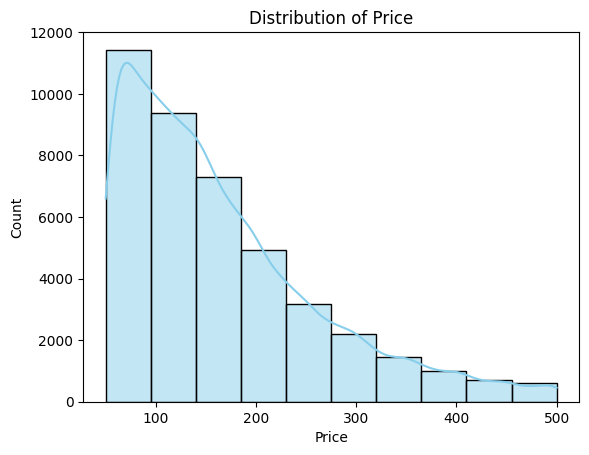

In [677]:
### DISTRIBUTIONS
sns.histplot(data=train_df, x='price', bins=10, kde=True, color='skyblue')

plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Count')

price_median = train_df["price"].median()

print("The median price is $" + "{:.2f}".format(price_median))
print("The price is not normally distributed, it is right skewed.")




The median number of bedrooms is 1.00
The price is not normally distributed, it is right skewed.


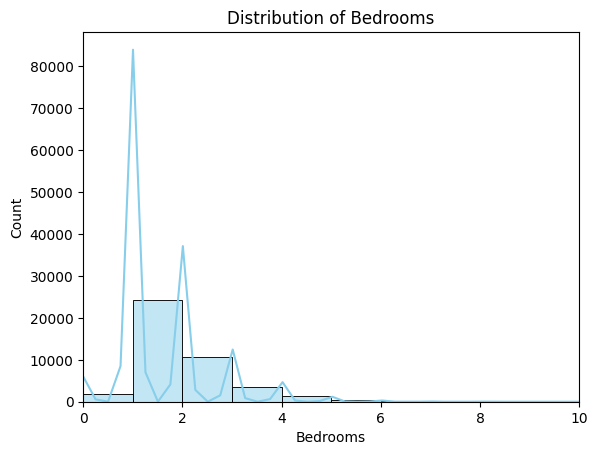

In [ ]:
sns.histplot(data=train_df, x='bedrooms', binwidth=1, kde=True, color='skyblue')

plt.title('Distribution of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
plt.xlim(0, 10)

bedrooms_median = train_df["bedrooms"].median()

print("The median number of bedrooms is " + "{:.2f}".format(bedrooms_median))
print("The number of bedrooms is not normally distributed, it is right skewed.")

The median number of bathrooms is 1.00
The number of bathrooms is not normally distributed, it is right skewed.


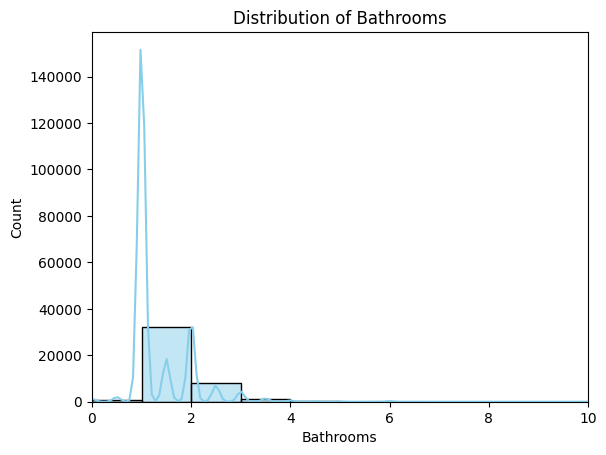

In [681]:
sns.histplot(data=train_df, x='bathrooms', binwidth=1, kde=True, color='skyblue')

plt.title('Distribution of Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Count')
plt.xlim(0, 10)

bathrooms_median = train_df["bathrooms"].median()

print("The median number of bathrooms is " + "{:.2f}".format(bathrooms_median))
print("The number of bathrooms is not normally distributed, it is right skewed.")

The median number of accommodates is 3.00
Accommodates is not normally distributed, it is right skewed.


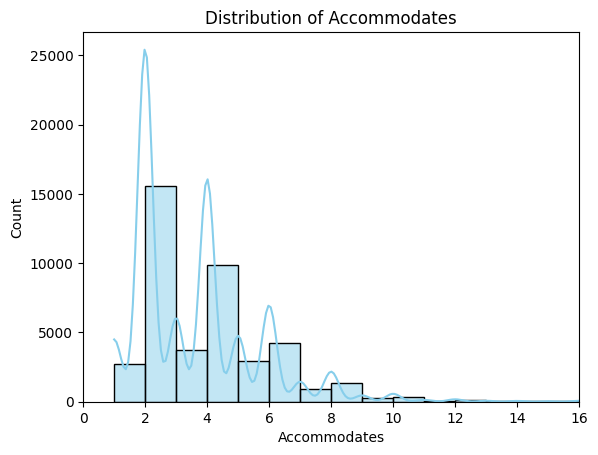

In [683]:
sns.histplot(data=train_df, x='accommodates', binwidth=1, kde=True, color='skyblue')

plt.title('Distribution of Accommodates')
plt.xlabel('Accommodates')
plt.ylabel('Count')
plt.xlim(0, 16)

accommodates_median = train_df["accommodates"].median()

print("The median number of accommodates is " + "{:.2f}".format(accommodates_median))
print("Accommodates is not normally distributed, it is right skewed.")

In [684]:
print("Bedrooms, bathrooms, and accommodates are all right-skewed like price, each concentrated at low values with a long tail toward larger listings; accommodates also shows a zigzag pattern where even numbers (2, 4, 6) spike higher than neighboring odd numbers, likely reflecting that most rooms/beds are configured to sleep guests in pairs.")

Bedrooms, bathrooms, and accommodates are all right-skewed like price, each concentrated at low values with a long tail toward larger listings; accommodates also shows a zigzag pattern where even numbers (2, 4, 6) spike higher than neighboring odd numbers, likely reflecting that most rooms/beds are configured to sleep guests in pairs.


In [654]:
print("The following are the number of unique values in each non-numeric column")

for col in train_df.columns:
    if not pd.api.types.is_numeric_dtype(train_df[col]):
        print(col + ": " + str(train_df[col].nunique()))

The following are the number of unique values in each non-numeric column
name: 41118
host_has_profile_pic: 2
host_identity_verified: 2
neighbourhood: 33
room_type: 4


0.03233606382661918

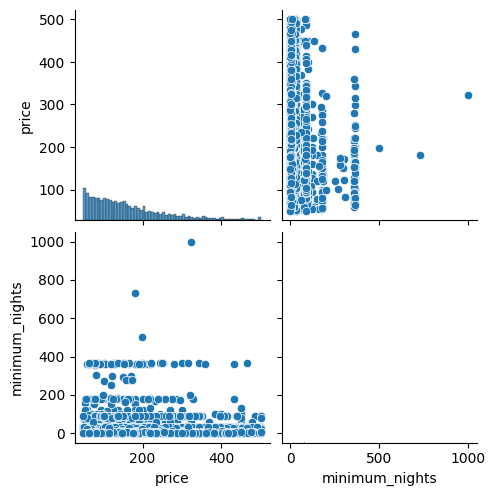

In [655]:
sns.pairplot(train_df, vars=["price", "minimum_nights"])
train_df["price"].corr(train_df["minimum_nights"])

The majority of listings have a `minimum_nights` value under 200, with a smaller cluster around 350–400. A few outlier listings require minimum stays of 500–1000 nights; these outliers tend to fall in the mid-to-upper price range rather than the low end, but with only a handful of such points, this isn't enough to establish a real trend. Excluding these outliers, the bulk of listings show minimum_nights scattered fairly independently of price, with no clear visual pattern of one increasing alongside the other. This is supported by a Pearson correlation coefficient of 0.03233606382661918 between price and minimum_nights, which indicates a negligible linear relationship between the two variables.

# Model preparation

In [656]:
train_df["host_has_profile_pic"].isna().sum()
train_df = train_df.dropna(subset=["host_has_profile_pic", "host_identity_verified", "bedrooms", "bathrooms", "beds"])

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
transformed = encoder.fit_transform(train_df[["neighbourhood", "room_type"]])

encoded_df = pd.DataFrame(data=transformed.toarray(), columns=encoder.get_feature_names_out(), index=train_df.index)

train_df = train_df.join(encoded_df).drop(columns=["neighbourhood", "room_type"])

mapping_dict = {'t': 1, 'f': 0}
train_df['host_has_profile_pic'] = train_df['host_has_profile_pic'].map(mapping_dict)
train_df['host_identity_verified'] = train_df['host_identity_verified'].map(mapping_dict)

test_df['host_has_profile_pic'] = test_df['host_has_profile_pic'].map(mapping_dict)
test_df['host_identity_verified'] = test_df['host_identity_verified'].map(mapping_dict)

test_transformed = encoder.transform(test_df[["neighbourhood", "room_type"]])

test_encoded_df = pd.DataFrame(
    data=test_transformed.toarray(),
    columns=encoder.get_feature_names_out(),
    index=test_df.index
)

test_df = test_df.join(test_encoded_df).drop(columns=["neighbourhood", "room_type"])

# Model

In [ ]:
train_df = train_df.drop(columns=['name', 'id', 'host_id'])
y = train_df['price']
X = train_df.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42
)

split_model = LinearRegression().fit(X_train, y_train)
test_predictions = split_model.predict(X_test)

rmse = math.sqrt(mean_squared_error(y_test, test_predictions))
rmse

65.7121289065179

In [658]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

baseline_tree = DecisionTreeRegressor(max_depth=10)
baseline_tree.fit(X_train, y_train)

y_pred = baseline_tree.predict(X_test) 

rmse = math.sqrt(mean_squared_error(y_test, y_pred))
rmse

65.66284898993645

In [659]:
test_bathrooms_bedrooms = list(zip(test_df["bathrooms"], test_df["bedrooms"]))
test_df["reviews_per_month"] = test_df["reviews_per_month"].fillna(
    pd.Series(test_bathrooms_bedrooms, index=test_df.index).map(reviews_per_month_group_means)
)
test_df["reviews_per_month"] = test_df["reviews_per_month"].fillna(reviews_per_month_overall_mean)

test_df["review_scores_rating"] = test_df["review_scores_rating"].fillna(
    pd.Series(test_bathrooms_bedrooms, index=test_df.index).map(review_scores_rating_group_means)
)
test_df["review_scores_rating"] = test_df["review_scores_rating"].fillna(review_scores_rating_overall_mean)

test_df["review_scores_accuracy"] = test_df["review_scores_accuracy"].fillna(
    pd.Series(test_bathrooms_bedrooms, index=test_df.index).map(review_scores_accuracy_group_means)
)
test_df["review_scores_accuracy"] = test_df["review_scores_accuracy"].fillna(review_scores_accuracy_overall_mean)

test_df["review_scores_cleanliness"] = test_df["review_scores_cleanliness"].fillna(
    pd.Series(test_bathrooms_bedrooms, index=test_df.index).map(review_scores_cleanliness_group_means)
)
test_df["review_scores_cleanliness"] = test_df["review_scores_cleanliness"].fillna(review_scores_cleanliness_overall_mean)

test_df["review_scores_checkin"] = test_df["review_scores_checkin"].fillna(
    pd.Series(test_bathrooms_bedrooms, index=test_df.index).map(review_scores_checkin_group_means)
)
test_df["review_scores_checkin"] = test_df["review_scores_checkin"].fillna(review_scores_checkin_overall_mean)

test_df["review_scores_communication"] = test_df["review_scores_communication"].fillna(
    pd.Series(test_bathrooms_bedrooms, index=test_df.index).map(review_scores_communication_group_means)
)
test_df["review_scores_communication"] = test_df["review_scores_communication"].fillna(review_scores_communication_overall_mean)

test_df["review_scores_location"] = test_df["review_scores_location"].fillna(
    pd.Series(test_bathrooms_bedrooms, index=test_df.index).map(review_scores_location_group_means)
)
test_df["review_scores_location"] = test_df["review_scores_location"].fillna(review_scores_location_overall_mean)

test_df["review_scores_value"] = test_df["review_scores_value"].fillna(
    pd.Series(test_bathrooms_bedrooms, index=test_df.index).map(review_scores_value_group_means)
)
test_df["review_scores_value"] = test_df["review_scores_value"].fillna(review_scores_value_overall_mean)


In [660]:
# 1. bathrooms/bedrooms/beds fills
test_df["bathrooms"] = test_df["bathrooms"].fillna(bathrooms_fill)
test_df["bedrooms"] = test_df["bedrooms"].fillna(bedrooms_fill)
test_df["beds"] = test_df["beds"].fillna(beds_fill)

# 2. drop the same columns you dropped from train_df
test_df = test_df.drop(columns=["neighbourhood_group", "license", "host_name", "name", "id", "host_id"])

# 3. has_review (already given, included for completeness)
test_df["has_review"] = test_df["last_review"].notna().astype(int)
test_df = test_df.drop(columns=["last_review"])

# 4. amenity_count, reusing the same function
test_df["amenity_count"] = test_df["amenities"].apply(count_amenities)
test_df = test_df.drop(columns=["amenities"])

test_df.shape 


(8199, 64)

In [661]:
set(X_train.columns) == set(test_df.columns)

True

# Test

In [662]:
test_df_ordered = test_df[X_train.columns]
test_predictions = split_model.predict(test_df_ordered).clip(min=0)


In [663]:
# save to CSV
df = pd.DataFrame()
df["price"] = test_predictions
df.to_csv("A4_predictions_MIAYUNIQUESOUTH.csv", index=False)

In [664]:
check_df = pd.read_csv("A4_predictions_MIAYUNIQUESOUTH.csv")
print(check_df.shape)
print(check_df["price"].min(), check_df["price"].max())
print(check_df["price"].isna().sum())

(8199, 1)
0.0 480.1359022281126
0


# Reflection

1. Which features were most predictive of nightly price? Were the results what you
expected, or were you surprised by anything?

Based on the Decision Tree's calculated feature importances, the following were most important: bedrooms (40%), room_type_Private room, bathrooms, neighbourhood_Westminster, calculated_host_listings_count, longitude, neighbourhood_Kensington and Chelsea, accommodates, latitude, and review_scores_location. I think these results are pretty expected since they have to do with location and the size of the rental property. I think it makes sense that a property in a more upscale neighborhood and/or a property with more space and rooms would amount to an increased nightly price. Something else that didn't suprise me was the lack of minimum_nights from the top importances list. I think that indicates that the minimum number of days a rental must be booked for doesn't necessarily impact the price of the rental nightly which I think makes sense logically. I think the minimum_nights is usually independently chosen by the host.

2. What does your model reveal about these Airbnb markets? For example: does
neighbourhood matter more than property size?

Looking at the percentages from the features importance list, features pertaining to size amount to ~60% of importance while those more related to location amount to ~15%. Additionally, of the 33 neighborhoods present in the data set, only 2 of them show in the feature list as having importance which implies that most neighborhoods don't impact nightly price that much which the exception of a few more fancy and expensive areas. The model reveals that rental size typically matters more than neighborhood.

3. What additional data would have improved your model? Name at least one variable not
present in the dataset that you believe would be a strong predictor of price, and explain
why.

I think a few additional variables could have improved the model. (1) I think many people list rentals with historical significance (famous people once stayed there, ghost attraction, etc) and that could lead to hosts increasing the price. (2) I think if a rental has a great view of the location is in, that could also lead to increased pricing. (3) I think it would've been interesting to see data showing the average home cost in the area the rental is in. Since most rentals are owned by hosts who may use the rental income to pay mortgage on the rental, that could affect how much they charge guests as well.

In [665]:
importances = pd.Series(baseline_tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(10)

bedrooms                                0.399190
room_type_Private room                  0.104926
bathrooms                               0.094824
neighbourhood_Westminster               0.056460
calculated_host_listings_count          0.047572
longitude                               0.042879
neighbourhood_Kensington and Chelsea    0.039602
accommodates                            0.034790
latitude                                0.030010
review_scores_location                  0.028708
dtype: float64